# Imports

In [1]:
import matplotlib as mpl
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['figure.figsize'] = (10, 4)
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['axes.linewidth'] = 2
mpl.rcParams['font.size'] = 16
mpl.rcParams['ytick.major.width'] = 2
mpl.rcParams['xtick.major.width'] = 2
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['xtick.major.size'] = 10

In [2]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root, minimize, root_scalar, minimize_scalar
from scipy.linalg import solve_discrete_lyapunov, block_diag
from scipy.signal import correlate, hilbert, spectrogram, periodogram, welch
from sklearn.base import BaseEstimator
from scipy.special import factorial
import warnings
import h5py
import glob
import os
warnings.filterwarnings("ignore", category=RuntimeWarning)
# warnings.filterwarnings("default", category=RuntimeWarning)

In [3]:
import sys
sys.path.append('../')

In [4]:
from helpers import *

In [5]:
rng = np.random.default_rng()

In [6]:
D = 2
C = 20

Fs = 1000
N = 3000

In [7]:
mu = 3*rng.random(size = C) - 6.5
# mu = [-4, -5, -3, -4.5, -3.5]

alphas = (0.9999 - 0.993)*rng.random(D) + 0.993
# freqs = [2.03, 8.97]
sigmas = [1e-4, 1e-4]

In [8]:
freqs = [0, 0]
while np.diff(freqs)[0]  < 4.5:
    freqs = np.round(9*rng.random(D) + 3.5, 2)
freqs

array([ 5.31, 10.13])

In [9]:
R_full = rotf(np.squeeze(freqs), Fs)
phi = np.repeat(alphas, 2)*R_full


U = rng.normal(0, scale=np.sqrt(np.repeat(sigmas, 2)).reshape(-1,1), size=(2*D,N))
X = np.zeros_like(U)
X[:, 0] = U[:, 0]
for k in range(1,N):
    X[:, k] = np.dot(phi, X[:, k-1]) + U[:, k-1]

# e_hat = np.tile([1,1], D)

# # beta = np.repeat([5, 2], 2)
# beta = np.array([5,5, 3,3])
# beta = (e_hat*beta).reshape(1, -1)

# beta2 = np.repeat([8, 4], 2)
# beta2 = (e_hat*beta2).reshape(1, -1)

In [10]:

betas = [np.repeat([rng.integers(2, 5), rng.integers(1, 3)], 2).reshape(1, -1) for _ in range(C)]
for i, bb in enumerate(betas):
    print(i, bb)

0 [[3 3 2 2]]
1 [[2 2 1 1]]
2 [[3 3 1 1]]
3 [[2 2 2 2]]
4 [[4 4 2 2]]
5 [[3 3 2 2]]
6 [[2 2 1 1]]
7 [[2 2 1 1]]
8 [[4 4 2 2]]
9 [[4 4 1 1]]
10 [[4 4 1 1]]
11 [[3 3 2 2]]
12 [[4 4 2 2]]
13 [[3 3 1 1]]
14 [[4 4 1 1]]
15 [[4 4 2 2]]
16 [[4 4 1 1]]
17 [[2 2 1 1]]
18 [[4 4 2 2]]
19 [[2 2 1 1]]


In [11]:
obs = []
for mu_c, beta_c in zip(mu, betas):
    obs.append(np.exp(mu_c + np.dot(beta_c, X)))
obs = np.vstack(obs)
y = (obs > rng.random((C, N)))*1
y.shape, obs.shape

((20, 3000), (20, 3000))

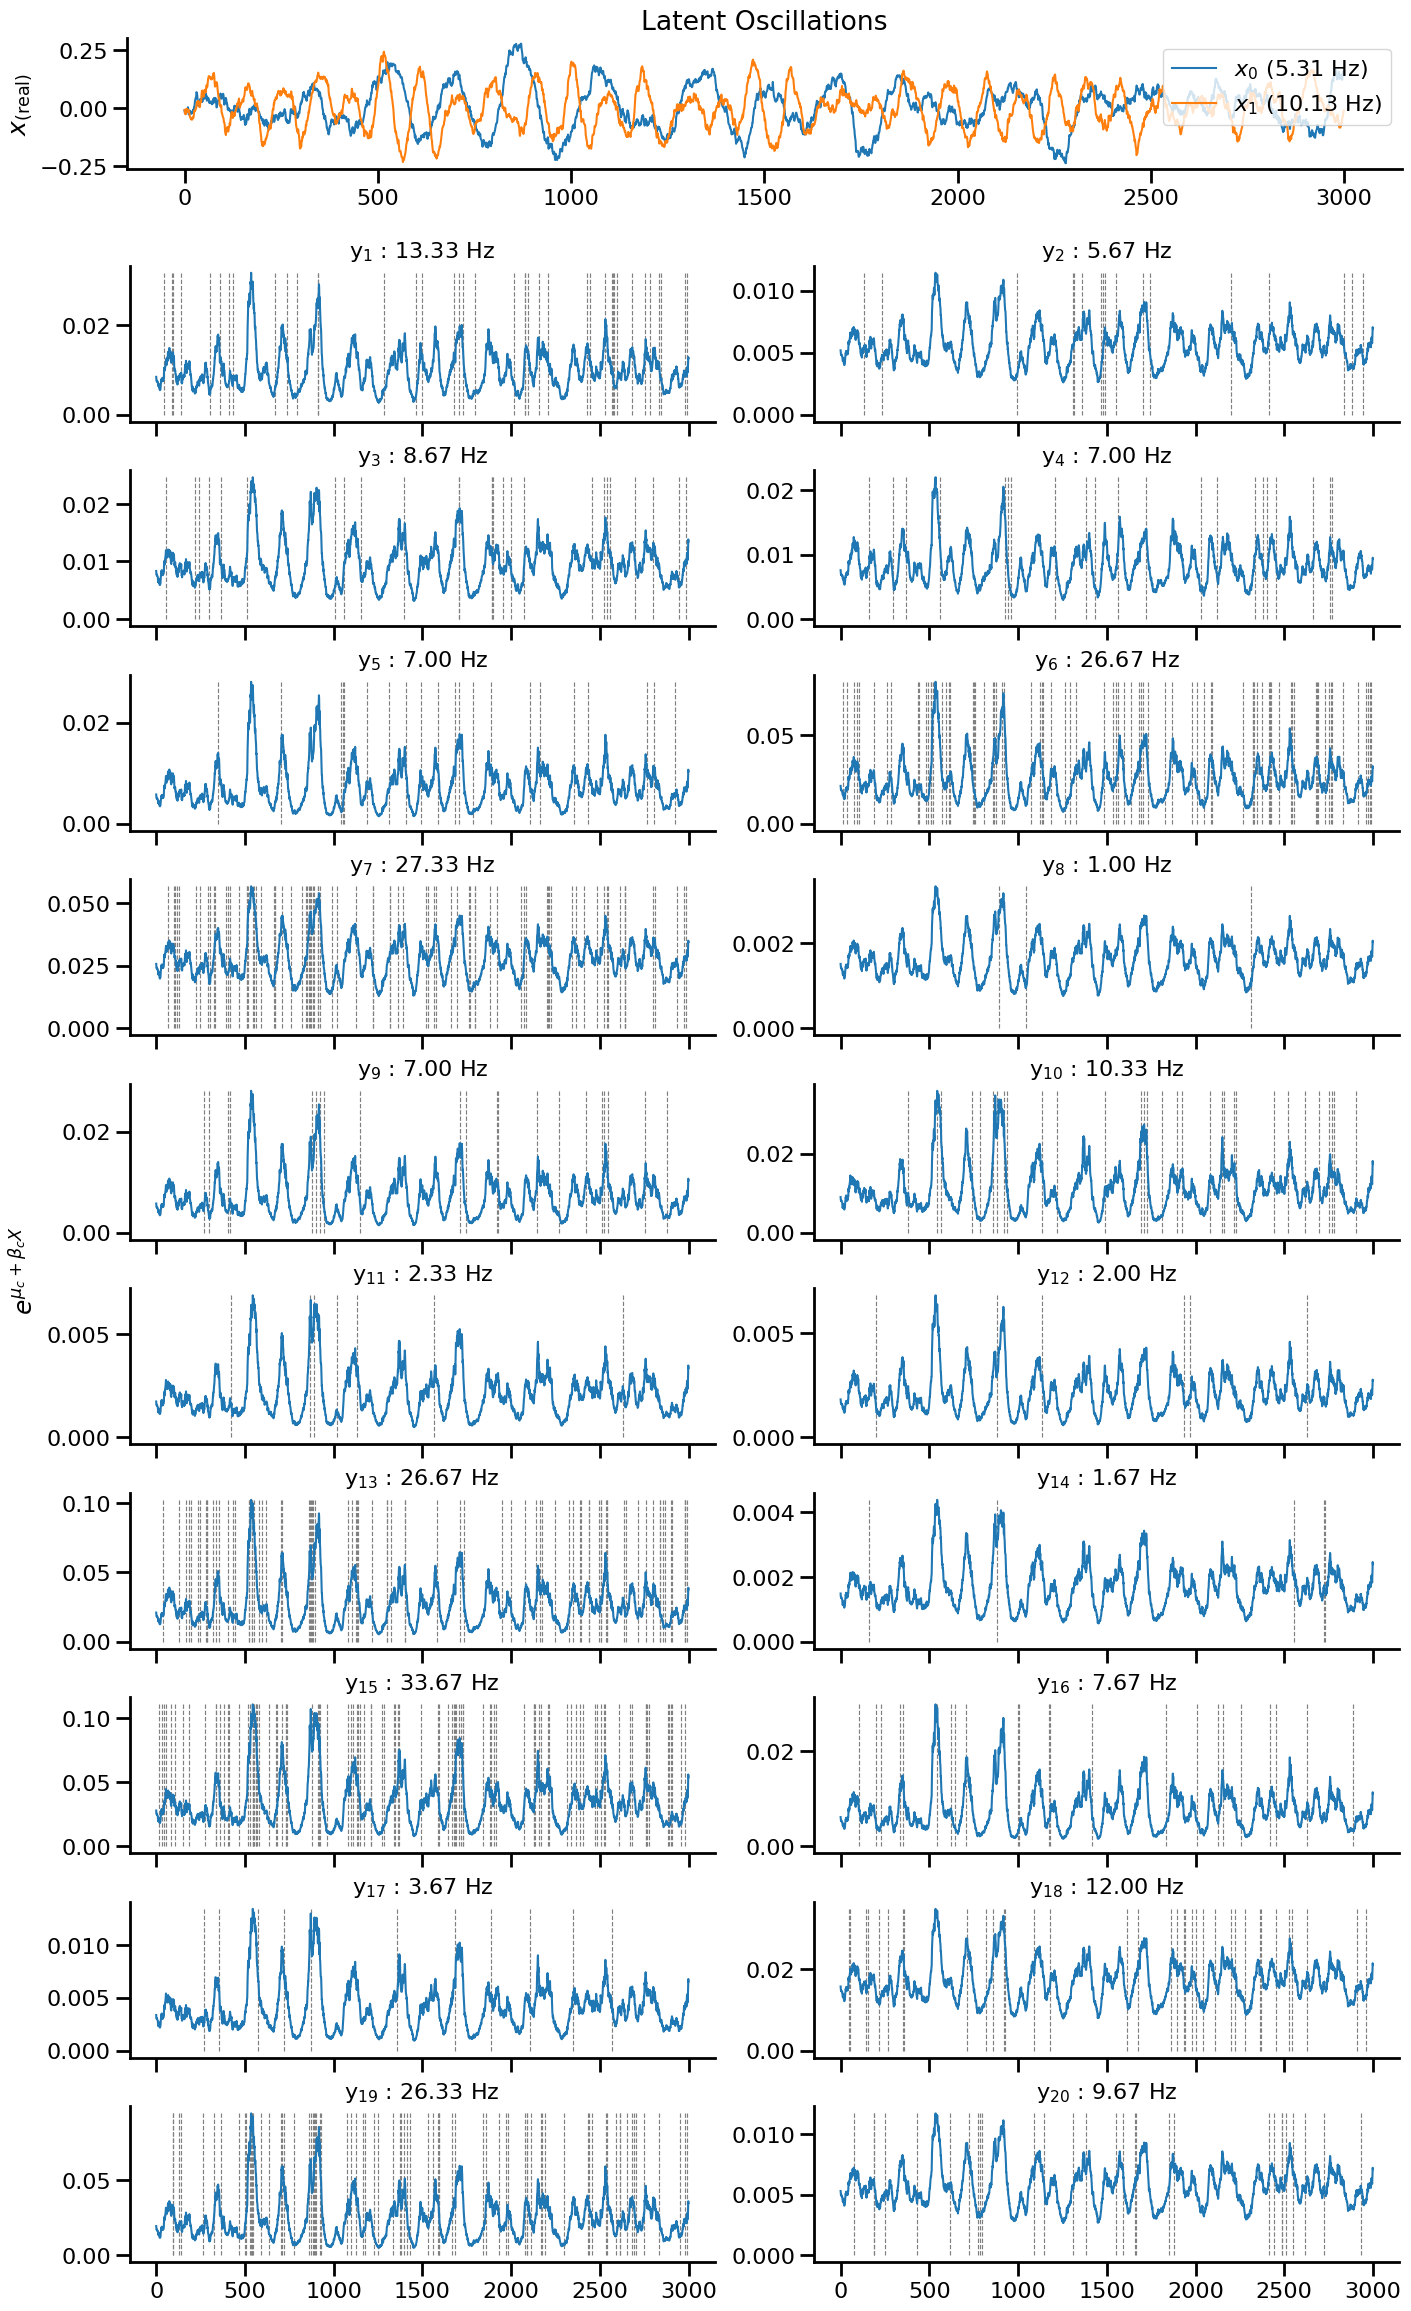

In [12]:

show_length = 5000
if C<=5:
    fig = plt.figure(figsize=(14,C*2 + 2), layout='constrained')
    subfigs = fig.subfigures(2,1, height_ratios=[1, C])
    axs = subfigs[1].subplots(C,1, sharex=True)
    
else:
    fig = plt.figure(figsize=(14,C + 3), layout='constrained')
    subfigs = fig.subfigures(2,1, height_ratios=[1, C//2])
    axs = subfigs[1].subplots(int(np.ceil(C/2)),2, sharex=True)

tax = subfigs[0].subplots()
for dim in range(D):
    # print(dim)
    # pdb.set_trace()
    tax.plot(X[dim*2], label=f'$x_{dim}$ ({np.array(freqs).reshape(-1)[dim]} Hz)')
    if N > show_length:
        xlm = rng.integers(0,N - show_length - 1)
        tax.set_xlim([xlm, xlm+show_length])
tax.legend()
tax.set_title('Latent Oscillations')
tax.set_ylabel('$x_\\text{(real)}$', fontsize=18)


for ci, ax in zip(np.arange(C), np.asarray(axs).ravel()):
    ax.vlines(np.where(y[ci])[0], ymin=0, ymax = obs[ci].max(), ls='--', color='grey', lw=0.85)
    ax.plot(obs[ci])
    if N > show_length:
        ax.set_xlim([xlm, xlm+show_length])
    
    ax.set_title(rf'y$_{{{ci+1}}}$ : {y[ci].mean()*Fs:.2f} Hz', fontsize=16)
subfigs[1].supylabel('$e^{\\mu_c + \\beta_c X}$', fontsize=18)
plt.show()

# Spike Osc

In [13]:
from SpikeOsc import SpikeOsc

In [14]:
y.shape

(20, 3000)

In [15]:
max_oscillations = 2
use_PF = False
use_reg = True
change_beta = True
est_EKF = SpikeOsc(Fs, max_oscillations, max_iter=150, use_PF = use_PF, use_reg = use_reg, change_beta=change_beta, verbose=True, track_params=False,
                                    log_dir=r'C:/Users/aditi/Documents/NBRC/Codes/Codes_from_server/SpikeOsc')

Log directory 'C:/Users/aditi/Documents/NBRC/Codes/Codes_from_server/SpikeOsc' already exists. Logs will be saved here.


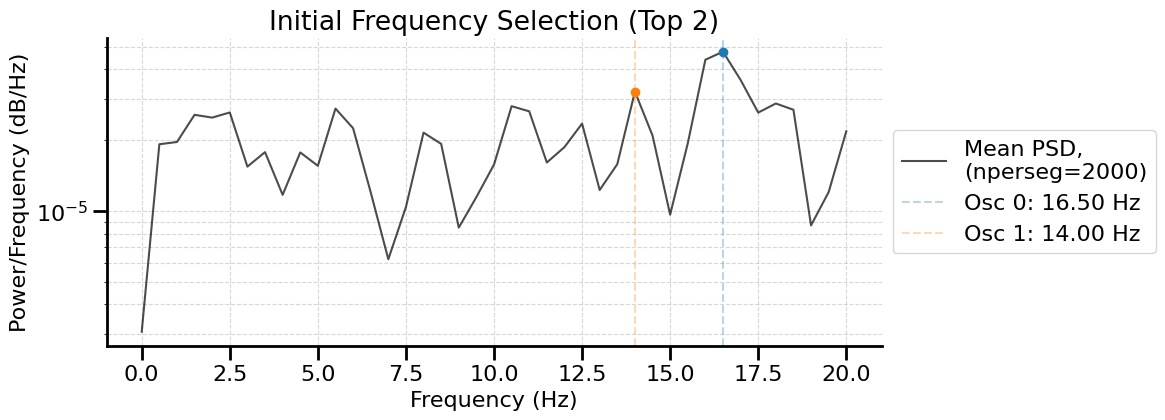

--> Initialized parameters for 2 oscillations:
		Frequencies: [16.5, 14.0]
		Alphas: [0.999 0.999]
		Sigmas: [0.0001 0.0001]
--> Detected 3 neurons
		Initialized mus: [-4.3175 -5.1732 -4.7483]
--> Using regularization with 
		gamma = 10, am = [40 17 26], bm = 3000


In [16]:
est_EKF._initialize_parameters(y[:3, :], plot_init=True, max_freq_init=20, nperseg=None)

In [17]:
freqs

array([ 5.31, 10.13])

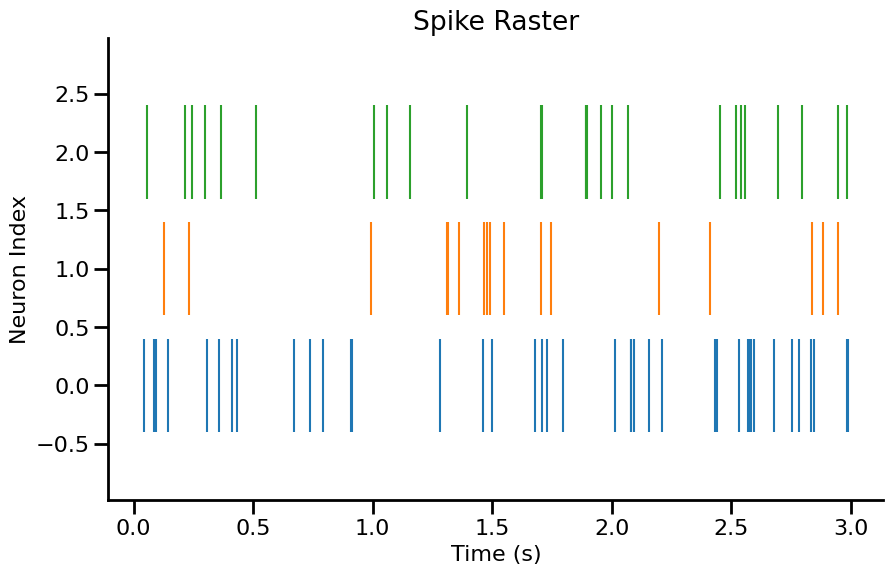

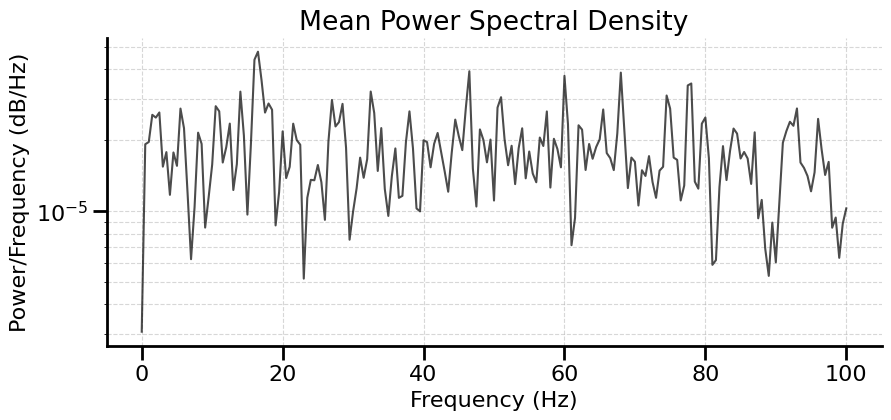

In [18]:
est_EKF.plot_raster()
est_EKF.plot_psd(max_frequency=100)

In [19]:
est_EKF.iterate()

Fitting model with 1 oscillation(s) 1 2 3 4 5 6 7 8 9 10 11 
Fitting model with 2 oscillation(s) 1 2 3 4 5 6 7 8 9 10 11 


Optimal number of oscillations: None
Log-likelihood at knee:None


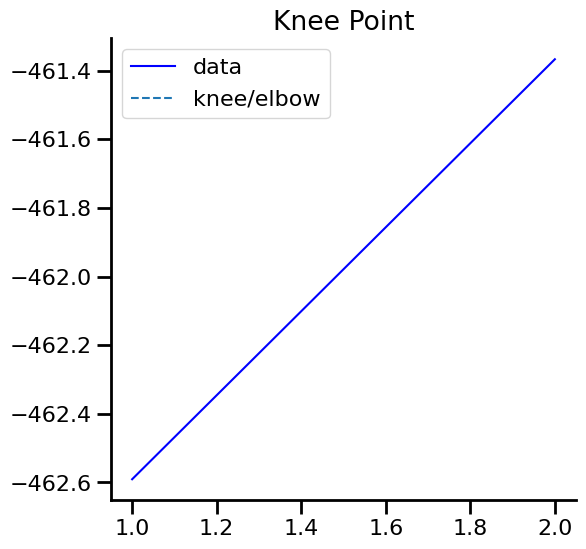

In [28]:
est_EKF.get_knee()

In [20]:
est = SpikeOsc(Fs, 4, max_iter=100, use_PF = True, 
                 N_particles = 1000, use_reg = False, early_stopping=True, patience=None, 
                 change_beta=True, assume_phase_lock = True, verbose=True, log_dir=r'C:/Users/aditi/Documents/NBRC/Codes/Codes_from_server/SpikeOsc')

Log directory 'C:/Users/aditi/Documents/NBRC/Codes/Codes_from_server/SpikeOsc' already exists. Logs will be saved here.


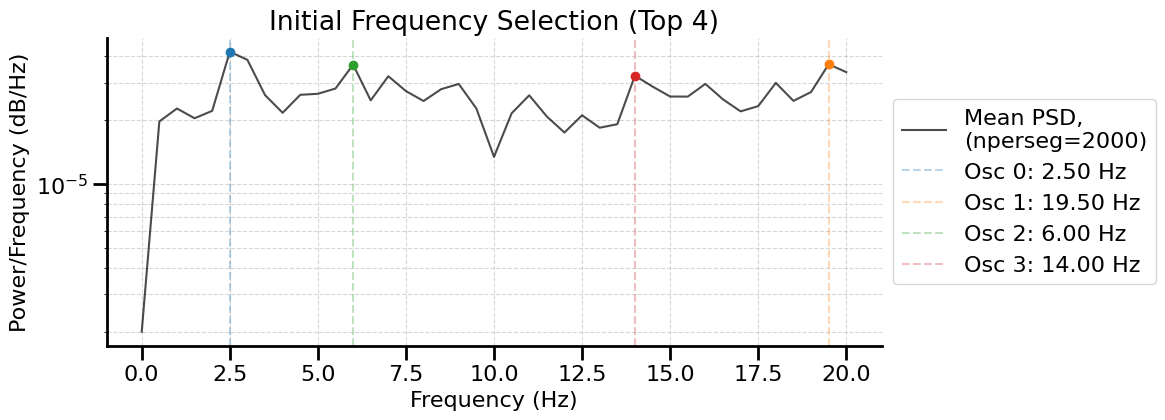

--> Initialized parameters for 4 oscillations:
		Frequencies: [2.5, 19.5, 6.0, 14.0]
		Alphas: [0.999 0.999 0.999 0.999]
		Sigmas: [0.0001 0.0001 0.0001 0.0001]
--> Detected 10 neurons
		Initialized mus: [-4.3175 -5.1732 -4.7483 -4.9618 -4.9618 -3.6243 -3.5996 -6.9078 -4.9618
 -4.5724]
--> Not using regularization


In [21]:
est._initialize_parameters(y[:10, :], plot_init=True, max_freq_init=20, nperseg=None)

In [22]:
freqs

array([ 5.31, 10.13])

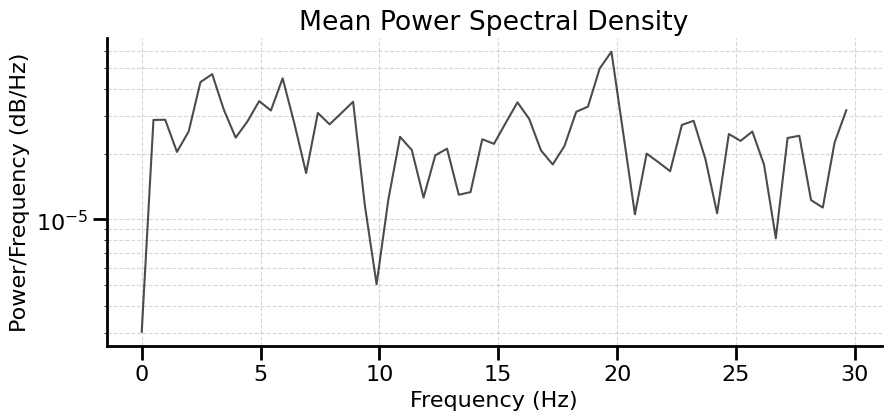

In [23]:
est.plot_psd(nperseg=2024, max_frequency=30)

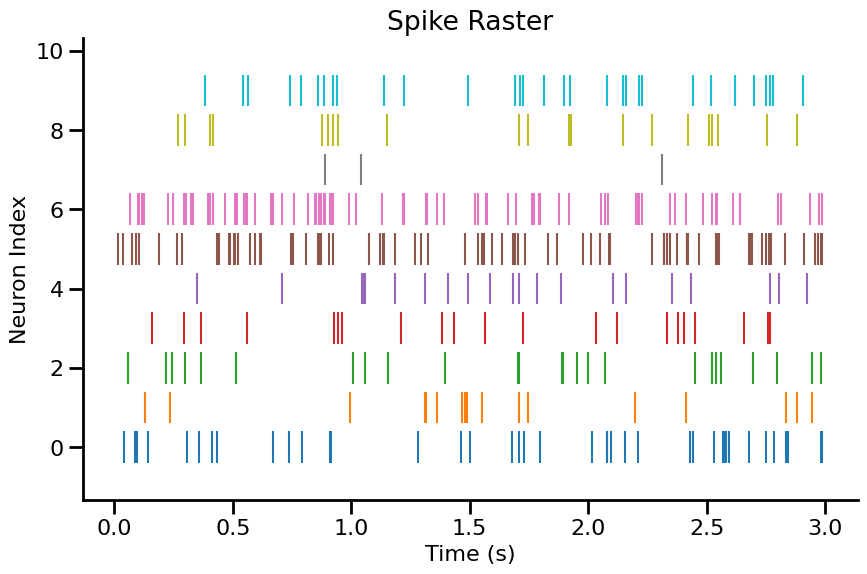

In [24]:
est.plot_raster()

In [25]:
est.n_neurons, est.max_oscillations

(10, 4)

In [26]:
est.track_params = False

In [27]:
est.iterate()

Fitting model with 1 oscillation(s) 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 
Fitting model with 2 oscillation(s) 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 
Fitting model with 3 oscillation(s) 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 

KeyboardInterrupt: 

In [ ]:
est.freq0

[6.0, 12.0, 1.0, 17.0]

In [ ]:
est.model_osc1['best_params']['freqs_']

[np.float64(5.854079116471282)]

In [ ]:
est.model_osc2['best_params']['freqs_']

[np.float64(5.8264293650055885), np.float64(11.45754938367925)]

1 [np.float64(5.854079116471282)] -2128.8844152229285
2 [np.float64(5.8264293650055885), np.float64(11.45754938367925)] -2115.284138655663
3 [np.float64(5.789393191518658), np.float64(11.70937489873945), np.float64(0.9898323620007674)] -2109.7510868269947
4 [np.float64(5.838397226749115), np.float64(11.947747472209713), np.float64(1.0764489419925496), np.float64(16.651548674096066)] -2108.472192936579


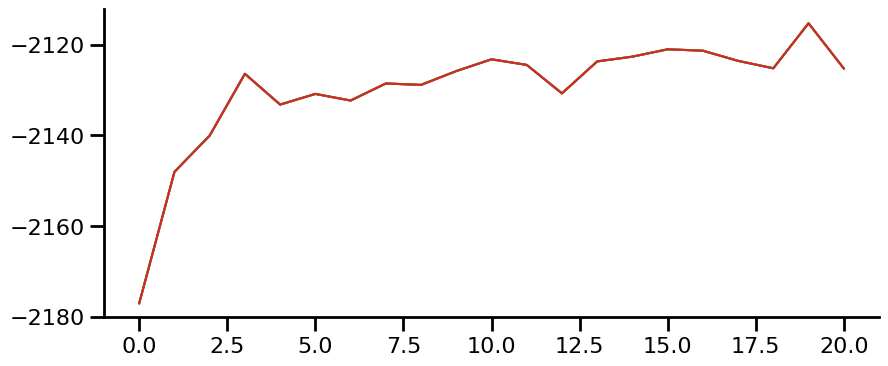

In [ ]:
logL_maxs = []
for ix in range(1,5):
    model = getattr(est, f'model_osc{ix}')
    plt.plot(est.model_osc2['logL_history'], label=f'model_osc{ix}')
    print(ix, model['best_params']['freqs_'], model['best_params']['logL'])
    logL_maxs.append(model['best_params']['logL'])
    

In [ ]:
from kneed import KneeLocator, find_shape

Optimal number of oscillations: None


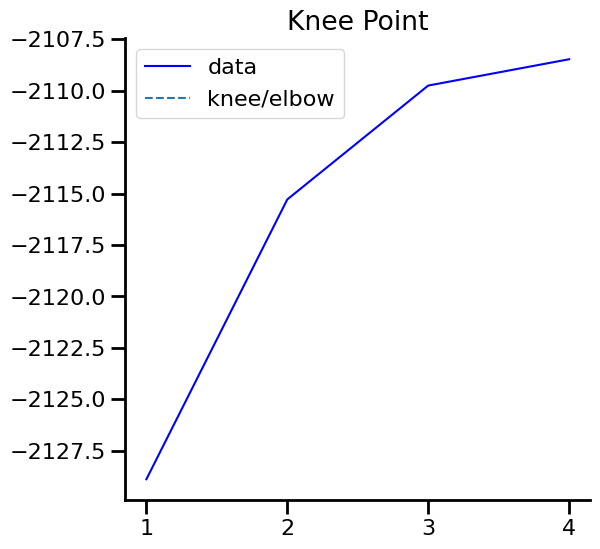

In [ ]:
direction, curve = find_shape(np.arange(1,5), logL_maxs)
kl = KneeLocator(np.arange(1,5), logL_maxs, curve=curve, direction=direction)
print(f"Optimal number of oscillations: {kl.knee}")
kl.plot_knee()

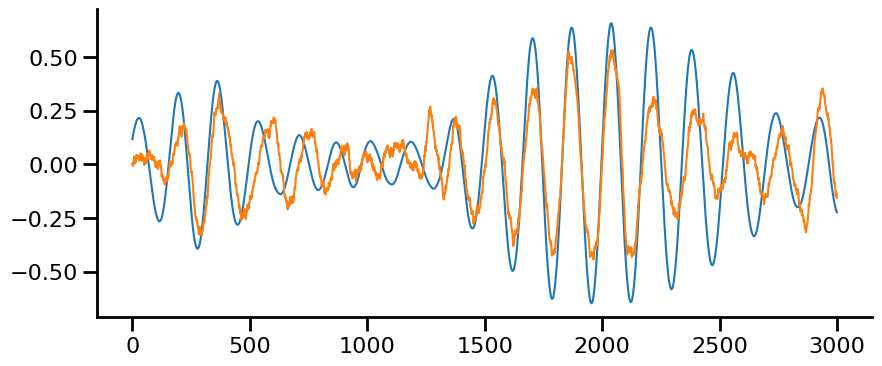

In [ ]:
plt.plot(est.model_osc4['best_hidden_states']['x_b'][0])
plt.plot(X[0])

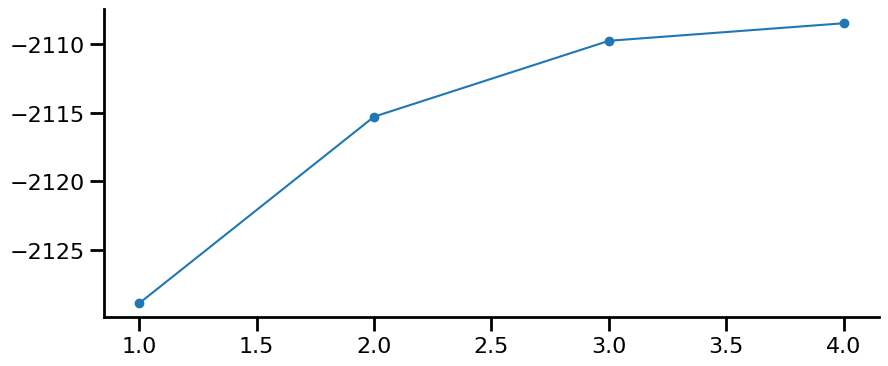

In [ ]:
plt.plot(np.arange(1,5), logL_maxs, marker='o')

In [ ]:
betas

[array([[3, 3, 2, 2]]),
 array([[2, 2, 1, 1]]),
 array([[2, 2, 2, 2]]),
 array([[3, 3, 1, 1]]),
 array([[2, 2, 1, 1]]),
 array([[2, 2, 1, 1]]),
 array([[3, 3, 2, 2]]),
 array([[2, 2, 1, 1]]),
 array([[4, 4, 2, 2]]),
 array([[2, 2, 2, 2]]),
 array([[4, 4, 2, 2]]),
 array([[4, 4, 1, 1]]),
 array([[4, 4, 2, 2]]),
 array([[4, 4, 1, 1]]),
 array([[3, 3, 2, 2]]),
 array([[4, 4, 1, 1]]),
 array([[2, 2, 2, 2]]),
 array([[4, 4, 1, 1]]),
 array([[4, 4, 1, 1]]),
 array([[3, 3, 1, 1]])]

In [ ]:
for ix in range(1,5):
    model = getattr(est, f'model_osc{ix}')
    print(ix, [np.round(b, 2) for b in model['best_params']['beta_'][:4]])

1 [array([[1.39, 3.68]]), array([[2.05, 3.65]]), array([[1.98, 1.9 ]]), array([[1.32, 2.19]])]
2 [array([[1.23, 4.07, 4.04, 2.76]]), array([[2.64, 3.92, 0.  , 0.  ]]), array([[1.72, 2.18, 5.82, 0.  ]]), array([[1.4 , 1.78, 0.11, 6.04]])]
3 [array([[1.57, 3.34, 2.14, 2.29, 0.  , 0.21]]), array([[1.4 , 2.11, 1.13, 0.72, 6.92, 1.96]]), array([[0.96, 1.26, 4.61, 0.  , 5.75, 0.44]]), array([[1.51, 1.61, 0.17, 3.6 , 0.09, 2.78]])]
4 [array([[1.29, 2.65, 3.17, 2.68, 0.  , 0.37, 4.  , 0.  ]]), array([[2.19, 2.19, 0.  , 0.09, 4.76, 0.  , 1.22, 0.  ]]), array([[0.94, 1.03, 5.61, 0.  , 6.66, 0.  , 0.  , 0.  ]]), array([[1.1 , 1.22, 1.19, 2.98, 0.39, 2.87, 6.43, 1.32]])]
